In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Prophet import
from prophet import Prophet

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Libraries imported!')
print('✅ Prophet ready!')

✅ Libraries imported!
✅ Prophet ready!


In [5]:
DATA_PATH = r"C:\demand_Forecasting\data" + "\\"

try:
    df = pd.read_csv(DATA_PATH + 'ca1_foods_daily.csv', parse_dates=['date'])
    print('✅ ca1_foods_daily.csv load ho gayi!')
except FileNotFoundError:
    print('⚠️  ca1_foods_daily.csv nahi mili — seedha bana raha hoon...')
    sales = pd.read_csv(DATA_PATH + 'sales_train_evaluation.csv')
    cal   = pd.read_csv(DATA_PATH + 'calendar.csv')
    id_cols  = ['id','item_id','dept_id','cat_id','store_id','state_id']
    day_cols = [c for c in sales.columns if c.startswith('d_')]
    long = sales[sales['store_id']=='CA_1'].melt(
        id_vars=id_cols, value_vars=day_cols, var_name='d', value_name='sales')
    long = long.merge(cal[['d','date']], on='d', how='left')
    long['date'] = pd.to_datetime(long['date'])
    df = long[long['cat_id']=='FOODS'].groupby('date')['sales'].sum().reset_index()
    df.to_csv(DATA_PATH + 'ca1_foods_daily.csv', index=False)
    print('✅ Data ready!')

print(f'Shape      : {df.shape}')
print(f'Date range : {df["date"].min()} → {df["date"].max()}')
df.head()

✅ ca1_foods_daily.csv load ho gayi!
Shape      : (1941, 2)
Date range : 2011-01-29 00:00:00 → 2016-05-22 00:00:00


,date,sales
0,2011-01-29,3239
1,2011-01-30,3137
2,2011-01-31,2008
3,2011-02-01,2258
4,2011-02-02,2032


In [6]:
# Prophet ka required format
prophet_df = df.rename(columns={'date': 'ds', 'sales': 'y'})

print('Prophet format:')
print(prophet_df.head())
print(f'\nColumns: {prophet_df.columns.tolist()}')  # ds aur y hona chahiye

Prophet format:
          ds     y
0 2011-01-29  3239
1 2011-01-30  3137
2 2011-01-31  2008
3 2011-02-01  2258
4 2011-02-02  2032

Columns: ['ds', 'y']


In [7]:
TEST_DAYS = 28

train = prophet_df.iloc[:-TEST_DAYS].copy()
test  = prophet_df.iloc[-TEST_DAYS:].copy()

print(f'Train : {len(train)} days ({train["ds"].min().date()} → {train["ds"].max().date()})')
print(f'Test  : {len(test)}  days ({test["ds"].min().date()} → {test["ds"].max().date()})')

Train : 1913 days (2011-01-29 → 2016-04-24)
Test  : 28  days (2016-04-25 → 2016-05-22)


In [8]:
print('🔄 Basic Prophet model train ho raha hai...')

model_basic = Prophet(
    yearly_seasonality  = True,   # Yearly pattern
    weekly_seasonality  = True,   # Weekly pattern
    daily_seasonality   = False,  # Daily nahi chahiye (daily data hai)
    seasonality_mode    = 'multiplicative'  # Sales data ke liye better
)

model_basic.fit(train)
print('✅ Basic Prophet trained!')

🔄 Basic Prophet model train ho raha hai...


14:35:30 - cmdstanpy - INFO - Chain [1] start processing
14:35:32 - cmdstanpy - INFO - Chain [1] done processing


✅ Basic Prophet trained!


In [9]:
!git add .

In [10]:
!git commit -m "imported all necessary libraries and training-testing data and trained Basic Prophet model"

[main 9c2fc8d] imported all necessary libraries and training-testing data and trained Basic Prophet model
 3 files changed, 363 insertions(+), 12 deletions(-)
 create mode 100644 .ipynb_checkpoints/Prphet_model-checkpoint.ipynb
 create mode 100644 Prphet_model.ipynb


In [11]:
!git push

To https://github.com/chashak20/demand-forecasting-project.git
   d5839f1..9c2fc8d  main -> main


In [12]:
print('🔄 Prophet + Holidays model train ho raha hai...')

model_holidays = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'multiplicative'
)

# US holidays add karo (Walmart US mein hai!)
model_holidays.add_country_holidays(country_name='US')

model_holidays.fit(train)
print('✅ Prophet + US Holidays trained!')

🔄 Prophet + Holidays model train ho raha hai...


14:38:08 - cmdstanpy - INFO - Chain [1] start processing
14:38:09 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet + US Holidays trained!


In [13]:
# Future dataframe banao (test dates ke liye)
future = model_basic.make_future_dataframe(periods=TEST_DAYS)

# Basic model forecast
forecast_basic    = model_basic.predict(future)
forecast_holidays = model_holidays.predict(future)

# Sirf test period ki predictions lo
pred_basic    = forecast_basic.tail(TEST_DAYS)['yhat'].values
pred_holidays = forecast_holidays.tail(TEST_DAYS)['yhat'].values

# Negative values ko 0 karo (sales negative nahi hoti)
pred_basic    = np.maximum(pred_basic, 0)
pred_holidays = np.maximum(pred_holidays, 0)

print('✅ Forecasts ready!')
print(f'Basic    first prediction : {pred_basic[0]:.1f}')
print(f'Holidays first prediction : {pred_holidays[0]:.1f}')
print(f'Actual   first value      : {test["y"].iloc[0]:.1f}')

✅ Forecasts ready!
Basic    first prediction : 2738.0
Holidays first prediction : 2702.6
Actual   first value      : 2893.0


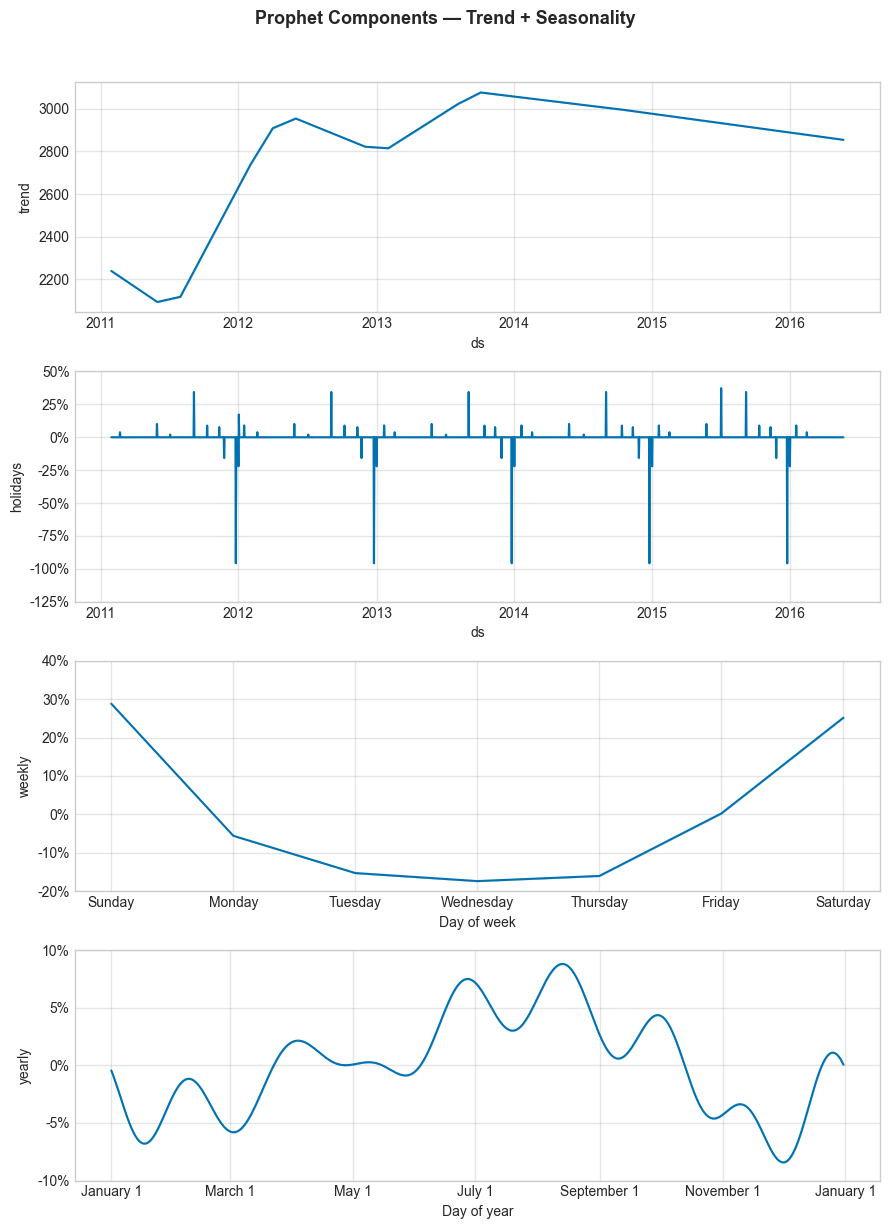

💾 prophet_components.png saved!

Ye plot 3 cheezein dikhata hai:
  1. Trend    — overall bhadh/ghat rahi hai sales
  2. Weekly   — har week ka pattern
  3. Yearly   — har saal ka pattern


In [17]:
# Prophet ka khaas feature — components dikhata hai!
# Trend, Weekly, Yearly — alag alag
fig = model_holidays.plot_components(forecast_holidays)
fig.suptitle('Prophet Components — Trend + Seasonality', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 prophet_components.png saved!')
print()
print('Ye plot 3 cheezein dikhata hai:')
print('  1. Trend    — overall bhadh/ghat rahi hai sales')
print('  2. Weekly   — har week ka pattern')
print('  3. Yearly   — har saal ka pattern')

In [ ]:
!git add 